## <center>NLP: AI-Powered Customer Support Assistant using Transformer Models</center>

#### This project aims building an end-to-end, real-world AI project using NLP and transformer-based models.  
The project uses: (PyTorch/TensorFlow, embeddings, tokenization, transformers, model training, evaluation, deployment, scaling, and free tools).

In [3]:
import os
import re
import json
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer


/opt/anaconda3/envs/seman_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# --- Base directories ---
BASE_DIR = Path().resolve()  # resolves to backend/ folder
DATA_DIR = BASE_DIR / "data"
RAW_CSV = DATA_DIR / "twcs.csv"   # downloaded CSV
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)  # create processed folder if missing

# --- Load CSV ---
df = pd.read_csv(RAW_CSV)
print("Original DataFrame shape:", df.shape)
print(df.head())
print(df.info())


/var/folders/p7/krbf_vbj2lqf31fmqjz_j8xm0000gn/T/ipykernel_32628/2056059286.py:9: DtypeWarning: Columns (1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_CSV)


Original DataFrame shape: (1048574, 7)
   tweet_id   author_id inbound                      created_at  \
0       1.0  sprintcare   False  Tue Oct 31 22:10:47 +0000 2017   
1       2.0      115712    True  Tue Oct 31 22:11:45 +0000 2017   
2       3.0      115712    True  Tue Oct 31 22:08:27 +0000 2017   
3       4.0  sprintcare   False  Tue Oct 31 21:54:49 +0000 2017   
4       5.0      115712    True  Tue Oct 31 21:49:35 +0000 2017   

                                                text response_tweet_id  \
0  @115712 I understand. I would like to assist y...                 2   
1      @sprintcare and how do you propose we do that               NaN   
2  @sprintcare I have sent several private messag...                 1   
3  @115712 Please send us a Private Message so th...                 3   
4                                 @sprintcare I did.                 4   

   in_response_to_tweet_id  
0                      3.0  
1                      1.0  
2                      4.0

In [7]:
# For TWCS: 'text' is user message, 'response_tweet_id' is agent's reply tweet_id
df = df.dropna(subset=['text', 'response_tweet_id']) 
print(df.shape)

(678, 7)


                                       text_question  \
0  @sprintcare I have sent several private messag...   
1                                 @sprintcare I did.   
2          @sprintcare is the worst customer service   
3  @sprintcare You gonna magically change your co...   
4  @sprintcare Since I signed up with you....Sinc...   

                                         text_answer  
0  @115712 I understand. I would like to assist y...  
1  @115712 Please send us a Private Message so th...  
2  @115712 Can you please send us a private messa...  
3                                                NaN  
4  @115713 We understand your concerns and we'd l...  
(203, 14)
Matched replies: 203
Unmatched replies: 6


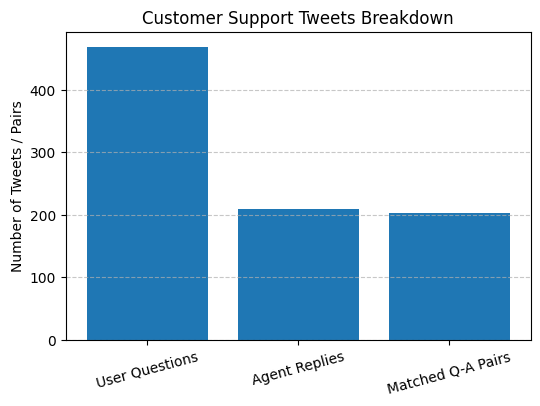

In [9]:
# We will merge with the actual reply text using:  response_tweet_id -> tweet_id mapping.

# We convert all ID columns to string
for col in ['tweet_id', 'response_tweet_id', 'in_response_to_tweet_id']:
    df[col] = df[col].astype(str)

# Step 2. Separate inbound (user) (inbound==true)  and outbound (agent) (inbound==false): we create two separate tables:
questions_df = df[df['inbound'] == True].copy()
replies_df = df[df['inbound'] == False].copy()

#Step 3. Merge user → agent reply pairs. We get a new qa_df (question-answer) table:
qa_df = questions_df.merge( replies_df, left_on='tweet_id', right_on='in_response_to_tweet_id', how='left',
    suffixes=('_question', '_answer'))


print(qa_df[['text_question', 'text_answer']].head())

# Step 4. we drop the questions that have no replies:
# questions_df.shape  ---> (469, 7)
# replies_df.shape    ---> (209, 7)
# qa_df.shape   ---> (469, 14)

qa_df = qa_df.dropna(subset=['text_answer'])
print(qa_df.shape)

# additional clarifications:

matched_reply_ids = qa_df['tweet_id_answer'].dropna().unique()
unmatched_replies = replies_df[~replies_df['tweet_id'].isin(matched_reply_ids)]

print(f"Matched replies: {len(matched_reply_ids)}")
print(f"Unmatched replies: {len(unmatched_replies)}")

counts = {
    'User Questions': len(questions_df),
    'Agent Replies': len(replies_df),
    'Matched Q-A Pairs': len(qa_df)
}

plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values())
plt.title("Customer Support Tweets Breakdown")
plt.ylabel("Number of Tweets / Pairs")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### We have qa_df data with questions-answers pairs. shape = (203, 14)  


#### Now, we clean the data from URLs, mentions, emojis etc.

In [13]:
# We create a clean text function to remove URL, @mentions, hashtags, special characters, emojis, extra spaces, and make lowercase: 

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()  # make lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)  # remove @mentions
    text = re.sub(r"#\w+", "", text)  # remove hashtags
    text = re.sub(r"[^a-z0-9\s.,!?']", " ", text)  # remove special chars/emojis
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

# Apply cleaning function to the dataset
qa_df['text_question'] = qa_df['text_question'].apply(clean_text)
qa_df['text_answer'] = qa_df['text_answer'].apply(clean_text)

# checking
print(qa_df[['text_question', 'text_answer']].sample(5, random_state=42))

# saving the cleaned data
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(exist_ok=True)

qa_df.to_csv(OUT_DIR / "cleaned_qa_pairs.csv", index=False)
qa_df.info()


                                         text_question  \
30            i don't fit in my veggie burrito costume   
16   what else can i provide? they refuse to help m...   
250  ok it was not a full flight, change had nothin...   
169  . item has not been delivered but tracking say...   
138  i ve asked your sales rep about the payments a...   

                                           text_answer  
30                 i still think you look great! becky  
16   we would not be able to verify anything withou...  
250  please remember that help is just a tweet away...  
169  i'm so sorry you didn't receive your parcel! w...  
138  apologies for all of the issues. if you have t...  
<class 'pandas.core.frame.DataFrame'>
Index: 203 entries, 0 to 467
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   tweet_id_question                 203 non-null    object
 1   author_id_question

________________________________________________________________________________________________________
________________________________________________________________________________________________________

<div style="text-align:center; line-height:1.5;">
<h3>2. Creating Embeddings → Semantic Search Setup (no model training)</h3>
<h3> FAISS for similarity search and clustering of dense vectors.</h3>
</div>

We use all-MiniLM-L6-v2 as a pre-trained embedding model from SentenceTransformers. It converts text into high-dimensional vectors (embeddings) that capture meaning — so similar sentences have similar vectors.

In [18]:
# improting the model
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# getting a list of all answers
answers = qa_df['text_answer'].tolist()

# Generate embeddings for all answers
embeddings = model.encode(answers, convert_to_numpy=True)

print("Embeddings shape:", embeddings.shape, embeddings.dtype)

Embeddings shape: (203, 384) float32


In [20]:
# importing FAISS 
import faiss

# to be sure that embeddings are float32
embeddings = embeddings.astype('float32') 

# ========= Build FAISS index =========

dimension = embeddings.shape[1]
print("Embeddings dimension:", dimension)
# Add embeddings to the index
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
print("Number of vectors in FAISS index:", index.ntotal)

# ========= Save index and embeddings =========
os.makedirs("embeddings", exist_ok=True)

faiss.write_index(index, "embeddings/faiss_index.index")
np.save("embeddings/answers.npy", answers)

print("FAISS index and embeddings saved successfully!")

# ========= Load index and answers (for app startup) =========
index = faiss.read_index("embeddings/faiss_index.index")
answers = np.load("embeddings/answers.npy", allow_pickle=True)

print("FAISS index and answers loaded successfully!")


Embeddings dimension: 384
Number of vectors in FAISS index: 203
FAISS index and embeddings saved successfully!
FAISS index and answers loaded successfully!


In [22]:
# Performing semantic search
query = "Do I need to check my email?"
query_vector = model.encode([query], convert_to_numpy=True).astype('float32')

# Search top-3 most similar answers
k = 3
distances, indices = index.search(query_vector, k)

print("Top 3 similar answers:")
for i in indices[0]:
    print("Answer:", qa_df.iloc[i]['text_answer'])
    print("Related question:", qa_df.iloc[i]['text_question'])
    print("Distance:", distances[0][list(indices[0]).index(i)])
    print("-" * 60)

Top 3 similar answers:
Answer: we'd recommend keeping an eye out on your email that is associated with your account for further info. ja
Related question: they have no info either..
Distance: 0.79660726
------------------------------------------------------------
Answer: we would not be able to verify anything without authenticating your account. jay
Related question: what else can i provide? they refuse to help me because they cannot validate the account...
Distance: 1.0404515
------------------------------------------------------------
Answer: hi david, confirmation emails can take up to 24 hrs. have you been waiting longer than this? helen
Related question: i made two bookings, but only received a confirmation email for one of the flights. little help?
Distance: 1.1946702
------------------------------------------------------------


In [24]:
import numpy as np

answers = np.load("embeddings/answers.npy", allow_pickle=True)
print(answers[:5])  # should print readable strings

['i understand. i would like to assist you. we would need to get you into a private secured link to further assist.'
 'please send us a private message so that we can further assist you. just click message at the top of your profile.'
 'can you please send us a private message, so that i can gain further details about your account?'
 "we understand your concerns and we'd like for you to please send us a direct message, so that we can further assist you. aa"
 "h there! we'd definitely like to work with you on this, how long have you been experiencing this issue? aa"]
